In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Consistent color used across all charts in this notebook and the
# Streamlit dashboard, for a unified look.
MAIN_COLOR = "#0B7285"

df_jobs = pd.read_csv("../data/processed/jobs_clean.csv")
df_skills = pd.read_csv("../data/processed/skills_clean.csv")

## Top 15 most in-demand skills

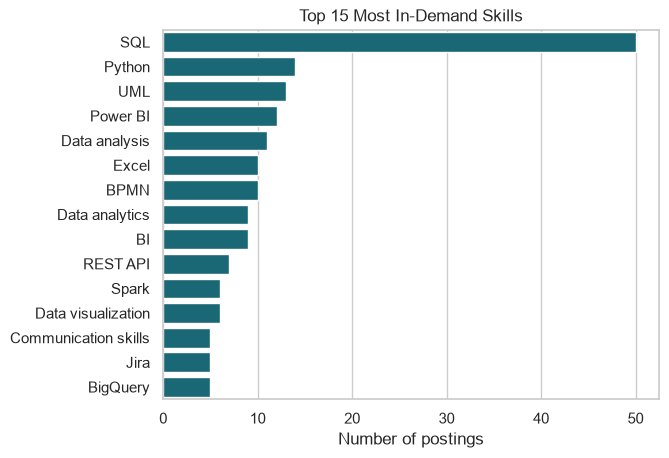

In [43]:
top_skills_df = df_skills["skills"].value_counts().head(15).reset_index()
top_skills_df.columns = ["skill", "count"]

sns.barplot(data=top_skills_df, x="count", y="skill", color=MAIN_COLOR)
plt.title("Top 15 Most In-Demand Skills")
plt.xlabel("Number of postings")
plt.ylabel("")
# plt.show() suppresses the raw Axes object output that Jupyter
# would otherwise print above the chart.
plt.show()

SQL towers over every other skill — the chart makes the gap impossible
to miss. Everything past the top 4-5 skills tails off gradually,
suggesting a few "must-have" tools and a long list of nice-to-haves.

## Salary distribution

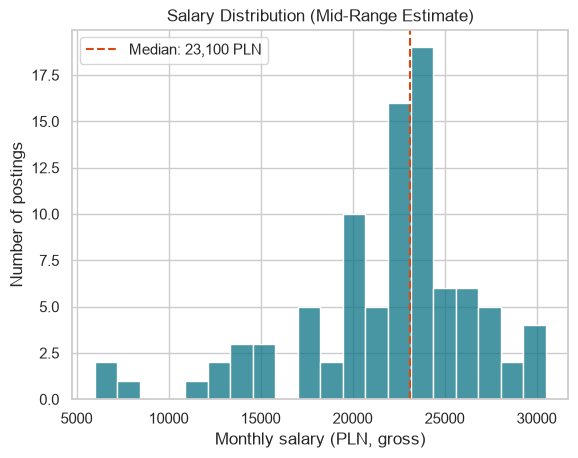

In [44]:
median_salary = df_jobs["mid_salary"].median()

sns.histplot(df_jobs["mid_salary"], color=MAIN_COLOR, bins=20)
plt.axvline(x=median_salary, color="#D9480F", linestyle="--", label=f"Median: {median_salary:,.0f} PLN")
plt.title("Salary Distribution (Mid-Range Estimate)")
plt.xlabel("Monthly salary (PLN, gross)")
plt.ylabel("Number of postings")
plt.legend()
plt.show()

Most salaries cluster tightly around the median (23,100 PLN), with a
visible secondary cluster around 15,000-19,000 PLN — possibly reflecting
less senior or hybrid roles. The distribution has a long tail toward
higher salaries, typical of senior/specialized postings.

## Salary by experience level

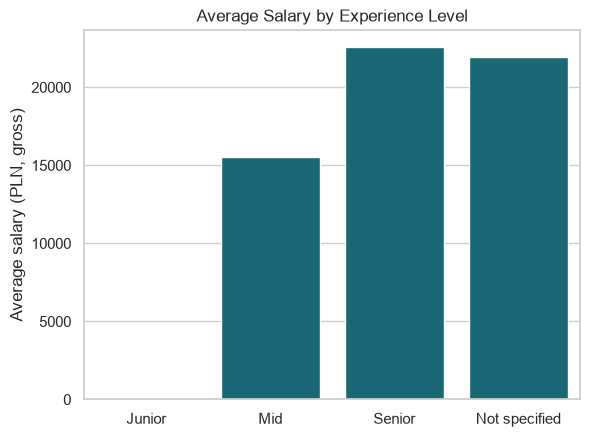

In [45]:
def get_experience_level(title):
    if "Junior" in title:
        return "Junior"
    elif "Senior" in title:
        return "Senior"
    elif "Mid" in title:
        return "Mid"
    else:
        return "Not specified"

df_jobs["experience_level"] = df_jobs["title"].apply(get_experience_level)

level_order = ["Junior", "Mid", "Senior", "Not specified"]

sns.barplot(
    data=df_jobs[df_jobs["mid_salary"].notna()],
    x="experience_level",
    y="mid_salary",
    order=level_order,
    color=MAIN_COLOR,
    errorbar=None,
)
plt.title("Average Salary by Experience Level")
plt.xlabel("")
plt.ylabel("Average salary (PLN, gross)")
plt.show()

Senior roles pay the most (22,700 PLN average), closely followed by
postings that don't specify a level (2,000 PLN) — likely a mix of
Mid and Senior roles. Mid-level postings, based on just 2 samples,
pay noticeably less — but this sample is too small to draw a firm
conclusion. No Junior postings exist in this dataset.

## English requirement and remote work

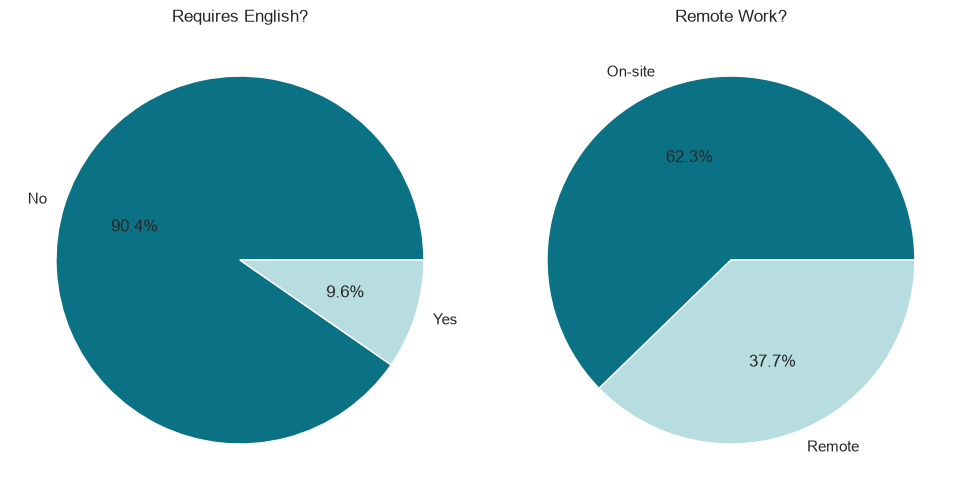

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

english_counts = df_jobs["has_english"].value_counts()
axes[0].pie(english_counts, labels=["No", "Yes"], autopct="%1.1f%%", colors=[MAIN_COLOR, "#B8DDE1"])
axes[0].set_title("Requires English?")

remote_counts = df_jobs["is_remote"].value_counts()
axes[1].pie(remote_counts, labels=["On-site", "Remote"], autopct="%1.1f%%", colors=[MAIN_COLOR, "#B8DDE1"])
axes[1].set_title("Remote Work?")

plt.tight_layout()
plt.show()

Only 9.6% of postings explicitly require English — though this likely
understates the real share (see NOTES.md). Remote work is far more
common: 37.7% of postings offer it, meaning over a third of Data/BI
Analyst roles in Poland don't require being on-site.